In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("aug_train.csv")

df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [3]:
df.shape

(19158, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [5]:
df["target"].value_counts()

target
0.0    14381
1.0     4777
Name: count, dtype: int64

In [6]:
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [7]:
df.isnull().sum().sort_values(ascending=False)

company_type              6140
company_size              5938
gender                    4508
major_discipline          2813
education_level            460
last_new_job               423
enrolled_university        386
experience                  65
enrollee_id                  0
city                         0
relevent_experience          0
city_development_index       0
training_hours               0
target                       0
dtype: int64

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

company_type              32.049274
company_size              30.994885
gender                    23.530640
major_discipline          14.683161
education_level            2.401086
last_new_job               2.207955
enrolled_university        2.014824
experience                 0.339284
enrollee_id                0.000000
city                       0.000000
relevent_experience        0.000000
city_development_index     0.000000
training_hours             0.000000
target                     0.000000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique()[:10])


enrollee_id:
[ 8949 29725 11561 33241   666 21651 28806   402 27107   699]

city:
['city_103' 'city_40' 'city_21' 'city_115' 'city_162' 'city_176'
 'city_160' 'city_46' 'city_61' 'city_114']

city_development_index:
[0.92  0.776 0.624 0.789 0.767 0.764 0.762 0.913 0.926 0.827]

gender:
['Male' nan 'Female' 'Other']

relevent_experience:
['Has relevent experience' 'No relevent experience']

enrolled_university:
['no_enrollment' 'Full time course' nan 'Part time course']

education_level:
['Graduate' 'Masters' 'High School' nan 'Phd' 'Primary School']

major_discipline:
['STEM' 'Business Degree' nan 'Arts' 'Humanities' 'No Major' 'Other']

experience:
['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16']

company_size:
[nan '50-99' '<10' '10000+' '5000-9999' '1000-4999' '10/49' '100-500'
 '500-999']

company_type:
[nan 'Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Other'
 'Public Sector' 'NGO']

last_new_job:
['1' '>4' 'never' '4' '3' '2' nan]

training_hours:
[ 36  47  83  52   8  24  

In [11]:
df["target"].value_counts(normalize=True) * 100

target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64

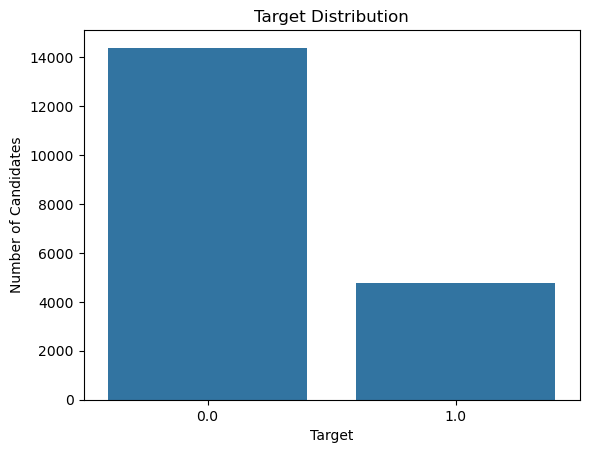

In [12]:
sns.countplot(x="target", data=df)

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Candidates")
plt.show()

In [13]:
df_clean = df.copy()

df_clean.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [14]:
df_clean["gender"] = df_clean["gender"].fillna("Unknown")

In [15]:
df_clean["education_level"] = df_clean["education_level"].fillna(
    df_clean["education_level"].mode()[0]
)

In [16]:
temp = df_clean.dropna(
    subset=["education_level", "enrolled_university"]
)

university_modes = temp.groupby("education_level")["enrolled_university"].agg(
    lambda x: x.mode()[0]
)

In [17]:
df_clean["enrolled_university"] = df_clean["enrolled_university"].fillna(
    df_clean["education_level"].map(university_modes)
)

In [18]:
df_clean["enrolled_university"] = df_clean["enrolled_university"].fillna(
    df_clean["enrolled_university"].mode()[0]
)

In [19]:
temp = df_clean.dropna(
    subset=["education_level", "major_discipline"]
)

major_modes = temp.groupby("education_level")["major_discipline"].agg(
    lambda x: x.mode()[0]
)

In [20]:
df_clean["major_discipline"] = df_clean["major_discipline"].fillna(
    df_clean["education_level"].map(major_modes)
)

In [21]:
df_clean["major_discipline"] = df_clean["major_discipline"].fillna(
    df_clean["major_discipline"].mode()[0]
)

In [22]:
temp = df_clean.dropna(
    subset=["relevent_experience", "experience"]
)

experience_modes = temp.groupby("relevent_experience")["experience"].agg(
    lambda x: x.mode()[0]
)

In [23]:
df_clean["experience"] = df_clean["experience"].fillna(
    df_clean["relevent_experience"].map(experience_modes)
)

In [24]:
df_clean["experience"] = df_clean["experience"].fillna(
    df_clean["experience"].mode()[0]
)

In [25]:
temp = df_clean.dropna(
    subset=["experience", "last_new_job"]
)

last_job_modes = temp.groupby("experience")["last_new_job"].agg(
    lambda x: x.mode()[0]
)
df_clean["last_new_job"] = df_clean["last_new_job"].fillna(
    df_clean["experience"].map(last_job_modes)
)
df_clean["last_new_job"] = df_clean["last_new_job"].fillna(
    df_clean["last_new_job"].mode()[0]
)

In [26]:
df_clean["company_type"] = df_clean["company_type"].fillna("Unknown")

In [27]:

company_size_modes = (
    df_clean[df_clean["company_size"].notna()]
    .groupby("company_type")["company_size"]
    .agg(lambda x: x.mode()[0])
)


df_clean["company_size"] = df_clean["company_size"].fillna(
    df_clean["company_type"].map(company_size_modes)
)


df_clean["company_size"] = df_clean["company_size"].fillna(
    df_clean["company_size"].mode()[0]
)

In [28]:
df_clean.isnull().sum().sort_values(ascending=False)

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

In [29]:
df_clean.dtypes

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

In [30]:
df_clean["experience"] = df_clean["experience"].replace({
    "<1": 0,
    ">20": 21
})

df_clean["experience"] = df_clean["experience"].astype(int)

df_clean["experience"].head()

0    21
1    15
2     5
3     0
4    21
Name: experience, dtype: int64

In [31]:
df_clean["last_new_job"] = df_clean["last_new_job"].replace({
    "never": 0,
    ">4": 5
})

df_clean["last_new_job"] = df_clean["last_new_job"].astype(int)

df_clean["last_new_job"].head()

0    1
1    5
2    0
3    0
4    4
Name: last_new_job, dtype: int64

In [32]:
df_clean["job_stability"] = (
    df_clean["last_new_job"] /
    (df_clean["experience"] + 1)
)

In [33]:
df_clean["low_experience"] = (
    df_clean["experience"] <= 2
).astype(int)

In [34]:
df_clean["recent_job_change"] = (
    df_clean["last_new_job"] <= 1
).astype(int)

In [35]:
df_clean["high_experience"] = (
    df_clean["experience"] >= 10
).astype(int)

In [36]:
company_size_mapping = {
    "<10": 0,
    "10/49": 1,
    "50-99": 2,
    "100-500": 3,
    "500-999": 4,
    "1000-4999": 5,
    "5000-9999": 6,
    "10000+": 7
}

df_clean["company_size"] = df_clean["company_size"].map(
    company_size_mapping
)

In [37]:
df_clean.to_csv("train_clean.csv", index=False)
print("train_clean.csv saved")

train_clean.csv saved


In [38]:
df_clean[["experience", "last_new_job"]].dtypes

experience      int64
last_new_job    int64
dtype: object

In [39]:
df_clean["relevent_experience"] = df_clean["relevent_experience"].map({
    "Has relevent experience": 1,
    "No relevent experience": 0
})

df_clean["relevent_experience"].value_counts()

relevent_experience
1    13792
0     5366
Name: count, dtype: int64

In [40]:
categorical_cols = df_clean.select_dtypes(include="object").columns

categorical_cols

Index(['city', 'gender', 'enrolled_university', 'education_level',
       'major_discipline', 'company_type'],
      dtype='object')

In [41]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


city:
city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
            ... 
city_111       3
city_129       3
city_121       3
city_140       1
city_171       1
Name: count, Length: 123, dtype: int64

gender:
gender
Male       13221
Unknown     4508
Female      1238
Other        191
Name: count, dtype: int64

enrolled_university:
enrolled_university
no_enrollment       14203
Full time course     3757
Part time course     1198
Name: count, dtype: int64

education_level:
education_level
Graduate          12058
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

major_discipline:
major_discipline
STEM               17305
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64

company_type:
company_type
Pvt Ltd                9817
Unknown                6140
Funded Startup         1001
Pu

In [42]:
education_mapping = {
    "Primary School": 0,
    "High School": 1,
    "Graduate": 2,
    "Masters": 3,
    "Phd": 4
}

df_clean["education_level"] = df_clean["education_level"].map(
    education_mapping
)

In [43]:
df_clean = pd.get_dummies(
    df_clean,
    columns=[
        "gender",
        "enrolled_university",
        "major_discipline",
        "company_type"
    ],
    drop_first=False
)

In [44]:
df_clean.shape

(19158, 34)

In [45]:
df_clean.columns

Index(['enrollee_id', 'city', 'city_development_index', 'relevent_experience',
       'education_level', 'experience', 'company_size', 'last_new_job',
       'training_hours', 'target', 'job_stability', 'low_experience',
       'recent_job_change', 'high_experience', 'gender_Female', 'gender_Male',
       'gender_Other', 'gender_Unknown',
       'enrolled_university_Full time course',
       'enrolled_university_Part time course',
       'enrolled_university_no_enrollment', 'major_discipline_Arts',
       'major_discipline_Business Degree', 'major_discipline_Humanities',
       'major_discipline_No Major', 'major_discipline_Other',
       'major_discipline_STEM', 'company_type_Early Stage Startup',
       'company_type_Funded Startup', 'company_type_NGO', 'company_type_Other',
       'company_type_Public Sector', 'company_type_Pvt Ltd',
       'company_type_Unknown'],
      dtype='object')

In [46]:
df_clean.isnull().sum().sort_values(ascending=False).head(20)

enrollee_id                             0
city                                    0
city_development_index                  0
relevent_experience                     0
education_level                         0
experience                              0
company_size                            0
last_new_job                            0
training_hours                          0
target                                  0
job_stability                           0
low_experience                          0
recent_job_change                       0
high_experience                         0
gender_Female                           0
gender_Male                             0
gender_Other                            0
gender_Unknown                          0
enrolled_university_Full time course    0
enrolled_university_Part time course    0
dtype: int64

In [47]:
df_clean = df_clean.drop(columns=["city"])

In [48]:
df_clean = df_clean.drop(columns=["enrollee_id"])

In [49]:
df_clean.shape

(19158, 32)

In [50]:
df_clean.select_dtypes(include="object").columns

Index([], dtype='object')

In [51]:
df_clean.select_dtypes(include=np.number).columns

Index(['city_development_index', 'relevent_experience', 'education_level',
       'experience', 'company_size', 'last_new_job', 'training_hours',
       'target', 'job_stability', 'low_experience', 'recent_job_change',
       'high_experience'],
      dtype='object')

In [52]:
numeric_cols = [
    "city_development_index",
    "experience",
    "last_new_job",
    "training_hours"
]

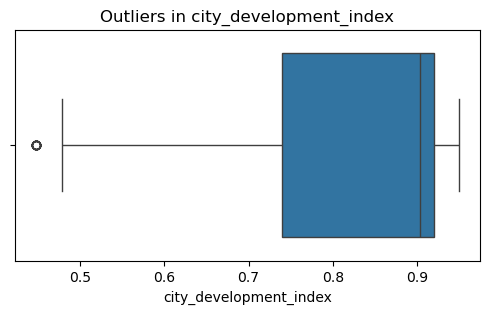

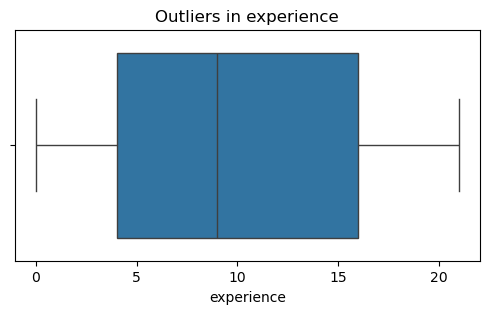

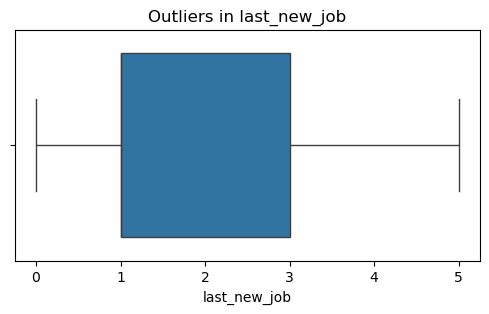

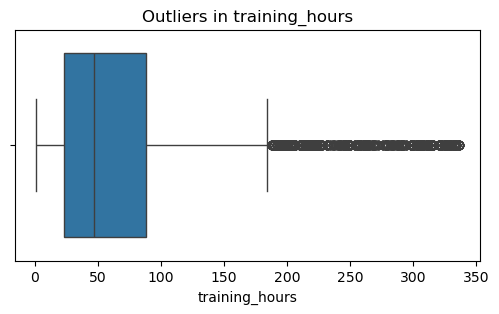

In [53]:
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [54]:
for col in numeric_cols:
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]
    
    print(f"{col}")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print()

city_development_index
Lower Bound: 0.4699999999999999
Upper Bound: 1.1900000000000002
Number of Outliers: 17

experience
Lower Bound: -14.0
Upper Bound: 34.0
Number of Outliers: 0

last_new_job
Lower Bound: -2.0
Upper Bound: 6.0
Number of Outliers: 0

training_hours
Lower Bound: -74.5
Upper Bound: 185.5
Number of Outliers: 984



In [55]:
for col in numeric_cols:
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ][col]
    
    print(f"\n{col}")
    print(outliers.sort_values().head(10))
    print("...")
    print(outliers.sort_values().tail(10))


city_development_index
1523     0.448
4744     0.448
5010     0.448
5265     0.448
5567     0.448
6127     0.448
7724     0.448
7864     0.448
9134     0.448
10401    0.448
Name: city_development_index, dtype: float64
...
7864     0.448
9134     0.448
10401    0.448
13549    0.448
14913    0.448
15114    0.448
16555    0.448
16784    0.448
17701    0.448
18065    0.448
Name: city_development_index, dtype: float64

experience
Series([], Name: experience, dtype: int64)
...
Series([], Name: experience, dtype: int64)

last_new_job
Series([], Name: last_new_job, dtype: int64)
...
Series([], Name: last_new_job, dtype: int64)

training_hours
7990     188
18745    188
8213     188
11539    188
14451    188
10563    188
6443     188
18002    188
6799     188
3192     188
Name: training_hours, dtype: int64
...
6322     336
16785    336
7121     336
15615    336
13929    336
4794     336
4397     336
4117     336
2056     336
18458    336
Name: training_hours, dtype: int64


In [56]:
X = df_clean.drop(columns=["target"])
y = df_clean["target"]

In [57]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19158, 31)
y shape: (19158,)


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [59]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (15326, 31)
X_val: (3832, 31)
y_train: (15326,)
y_val: (3832,)


In [60]:
print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

Train target distribution:
target
0.0    0.75062
1.0    0.24938
Name: proportion, dtype: float64

Validation target distribution:
target
0.0    0.750783
1.0    0.249217
Name: proportion, dtype: float64


In [61]:
X_train.columns

Index(['city_development_index', 'relevent_experience', 'education_level',
       'experience', 'company_size', 'last_new_job', 'training_hours',
       'job_stability', 'low_experience', 'recent_job_change',
       'high_experience', 'gender_Female', 'gender_Male', 'gender_Other',
       'gender_Unknown', 'enrolled_university_Full time course',
       'enrolled_university_Part time course',
       'enrolled_university_no_enrollment', 'major_discipline_Arts',
       'major_discipline_Business Degree', 'major_discipline_Humanities',
       'major_discipline_No Major', 'major_discipline_Other',
       'major_discipline_STEM', 'company_type_Early Stage Startup',
       'company_type_Funded Startup', 'company_type_NGO', 'company_type_Other',
       'company_type_Public Sector', 'company_type_Pvt Ltd',
       'company_type_Unknown'],
      dtype='object')

In [62]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X_train.columns
).sort_values(ascending=False)

mi_scores

city_development_index                  0.064718
company_type_Unknown                    0.023843
high_experience                         0.019832
job_stability                           0.016882
company_size                            0.016636
company_type_Pvt Ltd                    0.016199
enrolled_university_Full time course    0.014810
experience                              0.010892
recent_job_change                       0.010741
relevent_experience                     0.009836
enrolled_university_no_enrollment       0.009061
gender_Male                             0.007172
major_discipline_Arts                   0.005867
low_experience                          0.004319
company_type_Early Stage Startup        0.002819
major_discipline_Other                  0.002431
education_level                         0.002313
major_discipline_No Major               0.001569
gender_Unknown                          0.001211
last_new_job                            0.000938
company_type_NGO    

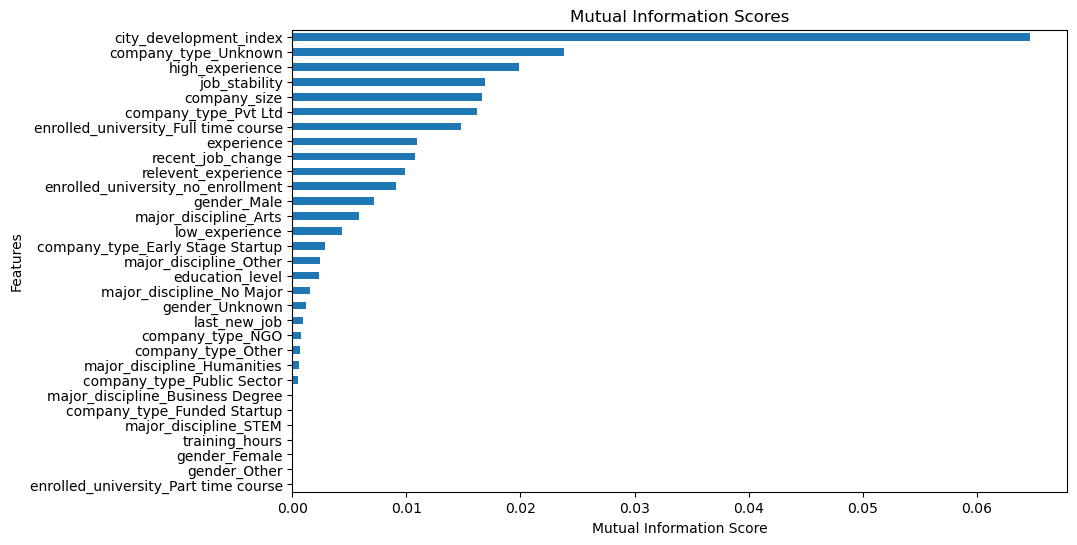

In [63]:
plt.figure(figsize=(10, 6))

mi_scores.sort_values().plot(kind="barh")

plt.title("Mutual Information Scores")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")

plt.show()

In [64]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

k_values = [5, 10, 15, 20, 25, 30]

results = []

for k in k_values:

    selector = SelectKBest(
        score_func=mutual_info_classif,
        k=k
    )

    X_train_k = selector.fit_transform(X_train, y_train)
    X_val_k = selector.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_k, y_train)

    y_val_prob = model.predict_proba(X_val_k)[:, 1]

    auc = roc_auc_score(y_val, y_val_prob)

    results.append({
        "k": k,
        "ROC-AUC": auc
    })

results_df = pd.DataFrame(results)

results_df

,k,ROC-AUC
0,5,0.774112
1,10,0.772725
2,15,0.777577
3,20,0.778765
4,25,0.776859
5,30,0.778306


In [65]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=15
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

X_val_selected = selector.transform(
    X_val
)

In [66]:
selected_features = X_train.columns[selector.get_support()]

selected_features

Index(['city_development_index', 'relevent_experience', 'experience',
       'company_size', 'job_stability', 'low_experience', 'recent_job_change',
       'high_experience', 'gender_Male', 'gender_Unknown',
       'enrolled_university_Full time course',
       'enrolled_university_no_enrollment', 'company_type_Public Sector',
       'company_type_Pvt Ltd', 'company_type_Unknown'],
      dtype='object')

In [67]:
print("X_train_selected shape:", X_train_selected.shape)
print("X_val_selected shape:", X_val_selected.shape)

X_train_selected shape: (15326, 15)
X_val_selected shape: (3832, 15)


In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(
    X_train_selected,
    y_train
)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [69]:
y_val_pred = logistic_model.predict(X_val_selected)
y_val_prob = logistic_model.predict_proba(X_val_selected)[:, 1]

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

Accuracy: 0.7635699373695198
Precision: 0.5584725536992841
Recall: 0.2450261780104712
F1 Score: 0.3406113537117904
ROC-AUC: 0.7765908350576061


In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_selected, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [72]:
y_val_pred_rf = rf_model.predict(X_val_selected)

y_val_prob_rf = rf_model.predict_proba(X_val_selected)[:, 1]

In [73]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Precision:", precision_score(y_val, y_val_pred_rf))
print("Recall:", recall_score(y_val, y_val_pred_rf))
print("F1 Score:", f1_score(y_val, y_val_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_rf))

Accuracy: 0.7575678496868476
Precision: 0.5133744855967078
Recall: 0.5225130890052356
F1 Score: 0.5179034769071095
ROC-AUC: 0.7592212656071715


In [74]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_selected, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [75]:
y_val_pred_gb = gb_model.predict(X_val_selected)

y_val_prob_gb = gb_model.predict_proba(X_val_selected)[:, 1]

In [76]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_gb))
print("Precision:", precision_score(y_val, y_val_pred_gb))
print("Recall:", recall_score(y_val, y_val_pred_gb))
print("F1 Score:", f1_score(y_val, y_val_pred_gb))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_gb))

Accuracy: 0.7873173277661796
Precision: 0.5839328537170264
Recall: 0.5099476439790576
F1 Score: 0.5444382336500838
ROC-AUC: 0.8101003262924766


In [77]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_selected, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [78]:
y_val_pred_xgb = xgb_model.predict(X_val_selected)

y_val_prob_xgb = xgb_model.predict_proba(X_val_selected)[:, 1]

In [79]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
print("Precision:", precision_score(y_val, y_val_pred_xgb))
print("Recall:", recall_score(y_val, y_val_pred_xgb))
print("F1 Score:", f1_score(y_val, y_val_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_xgb))

Accuracy: 0.7875782881002088
Precision: 0.5838287752675386
Recall: 0.5141361256544502
F1 Score: 0.5467706013363028
ROC-AUC: 0.8101698431503146


In [80]:
from sklearn.model_selection import GridSearchCV
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 3.009942438513867


In [81]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "scale_pos_weight": [1, scale_pos_weight, 2, 3]
}

In [82]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

In [83]:
grid_search.fit(
    X_train_selected,
    y_train
)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_delta_step=None, max_depth=3,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=200,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.03, 0.05, 0.1],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300],
                         'scale_pos_weight': [1, np.float64(3.009942438513867),
                                              2, 3]},
             scoring='roc_auc')

In [84]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'scale_pos_weight': 1}

Best Cross-Validation ROC-AUC:
0.7925636111941691


In [85]:
best_xgb = grid_search.best_estimator_

y_val_pred_tuned = best_xgb.predict(X_val_selected)

y_val_prob_tuned = best_xgb.predict_proba(X_val_selected)[:, 1]

In [86]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_tuned))
print("Precision:", precision_score(y_val, y_val_pred_tuned))
print("Recall:", recall_score(y_val, y_val_pred_tuned))
print("F1 Score:", f1_score(y_val, y_val_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_tuned))

Accuracy: 0.791231732776618
Precision: 0.5854465270121278
Recall: 0.556020942408377
F1 Score: 0.5703544575725027
ROC-AUC: 0.8117416156664063


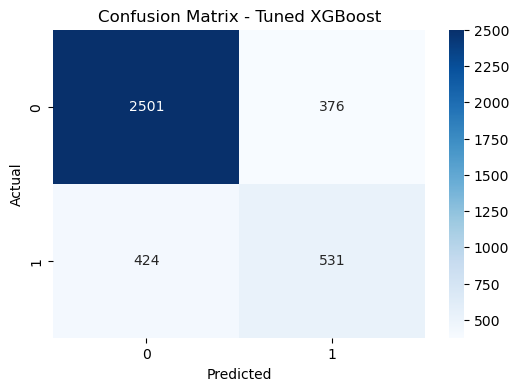

In [87]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

In [88]:
print(classification_report(y_val, y_val_pred_tuned))

              precision    recall  f1-score   support

         0.0       0.86      0.87      0.86      2877
         1.0       0.59      0.56      0.57       955

    accuracy                           0.79      3832
   macro avg       0.72      0.71      0.72      3832
weighted avg       0.79      0.79      0.79      3832



The tuned XGBoost model achieved 79% accuracy. It performed strongly in identifying candidates unlikely to change jobs, while achieving 75% recall for candidates likely to change jobs. The improved recall indicates that the model is better at identifying potential job changers, reducing the number of candidates who are incorrectly classified as unlikely to change jobs.

In [89]:
test_df = pd.read_csv("aug_test.csv")

test_clean = test_df.copy()

test_clean.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


In [90]:
test_clean.isnull().sum().sort_values(ascending=False)

company_type              634
company_size              622
gender                    508
major_discipline          312
education_level            52
last_new_job               40
enrolled_university        31
experience                  5
enrollee_id                 0
relevent_experience         0
city_development_index      0
city                        0
training_hours              0
dtype: int64

In [91]:
test_clean["gender"] = test_clean["gender"].fillna("Unknown")

In [92]:
test_clean["education_level"] = test_clean["education_level"].fillna(
    df["education_level"].mode()[0]
)

In [93]:
test_clean["enrolled_university"] = test_clean["enrolled_university"].fillna(
    test_clean["education_level"].map(university_modes)
)

In [94]:
test_clean["enrolled_university"] = test_clean["enrolled_university"].fillna(
    df["enrolled_university"].mode()[0]
)

In [95]:
test_clean["major_discipline"] = test_clean["major_discipline"].fillna(
    test_clean["education_level"].map(major_modes)
)

test_clean["major_discipline"] = test_clean["major_discipline"].fillna(
    df["major_discipline"].mode()[0]
)

In [96]:
test_clean["experience"] = test_clean["experience"].fillna(
    test_clean["relevent_experience"].map(experience_modes)
)

test_clean["experience"] = test_clean["experience"].fillna(
    df["experience"].mode()[0]
)

In [97]:
test_clean["experience"].isnull().sum()

np.int64(0)

In [98]:
test_clean["last_new_job"] = test_clean["last_new_job"].fillna(
    test_clean["experience"].map(last_job_modes)
)

test_clean["last_new_job"] = test_clean["last_new_job"].fillna(
    df["last_new_job"].mode()[0]
)

In [99]:
test_clean["last_new_job"].isnull().sum()

np.int64(0)

In [100]:
test_clean["company_type"] = test_clean["company_type"].fillna("Unknown")

In [101]:
test_clean["company_size"] = test_clean["company_size"].fillna(
    test_clean["company_type"].map(company_size_modes)
)

test_clean["company_size"] = test_clean["company_size"].fillna(
    df["company_size"].mode()[0]
)


In [102]:
test_clean["experience"] = test_clean["experience"].replace({
    "<1": 0,
    ">20": 21
})

test_clean["experience"] = test_clean["experience"].astype(int)

In [103]:
test_clean["last_new_job"] = test_clean["last_new_job"].replace({
    "never": 0,
    ">4": 5
})

test_clean["last_new_job"] = test_clean["last_new_job"].astype(int)

In [104]:
test_clean["relevent_experience"] = test_clean["relevent_experience"].map({
    "Has relevent experience": 1,
    "No relevent experience": 0
})

In [105]:
test_clean["job_stability"] = (
    test_clean["last_new_job"] /
    (test_clean["experience"] + 1)
)

test_clean["low_experience"] = (
    test_clean["experience"] <= 2
).astype(int)

test_clean["recent_job_change"] = (
    test_clean["last_new_job"] <= 1
).astype(int)

test_clean["high_experience"] = (
    test_clean["experience"] >= 10
).astype(int)

In [106]:
education_mapping = {
    "Primary School": 0,
    "High School": 1,
    "Graduate": 2,
    "Masters": 3,
    "Phd": 4
}

test_clean["education_level"] = test_clean["education_level"].map(
    education_mapping
)

In [107]:
company_size_mapping = {
    "<10": 0,
    "10/49": 1,
    "50-99": 2,
    "100-500": 3,
    "500-999": 4,
    "1000-4999": 5,
    "5000-9999": 6,
    "10000+": 7
}

test_clean["company_size"] = test_clean["company_size"].map(
    company_size_mapping
)

In [108]:
test_clean = pd.get_dummies(
    test_clean,
    columns=[
        "gender",
        "enrolled_university",
        "major_discipline",
        "company_type"
    ],
    drop_first=False
)

In [109]:
test_clean = test_clean.drop(
    columns=["enrollee_id", "city"]
)

In [110]:
X_test = test_clean.copy()

X_test.head()

,city_development_index,relevent_experience,education_level,experience,company_size,last_new_job,training_hours,job_stability,low_experience,recent_job_change,...,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,0.827,1,2,9,0,1,21,0.100000,0,1,...,False,False,True,False,False,False,False,False,False,True
1,0.920,1,2,5,2,1,98,0.166667,0,1,...,False,False,True,False,False,False,False,False,True,False
2,0.624,0,1,0,2,0,15,0.000000,1,1,...,False,False,True,False,False,False,False,False,True,False
3,0.827,1,3,11,1,1,39,0.083333,0,1,...,False,False,True,False,False,False,False,False,True,False
4,0.920,1,2,21,7,5,72,0.227273,0,0,...,False,False,True,False,False,False,False,False,True,False


In [111]:
X_test = X_test.reindex(
    columns=X.columns,
    fill_value=0
)

X_test.shape

(2129, 31)

In [112]:
test_clean["relevent_experience"].value_counts(dropna=False)

relevent_experience
1    1524
0     605
Name: count, dtype: int64

In [113]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

final_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=15
)

X_selected_full = final_selector.fit_transform(
    X,
    y
)

X_selected_full.shape

(19158, 15)

In [114]:
X_test_selected = final_selector.transform(
    X_test
)

X_test_selected.shape

(2129, 15)

In [115]:
final_xgb = XGBClassifier(
    **grid_search.best_params_,
    random_state=42,
    eval_metric="logloss"
)

final_xgb.fit(
    X_selected_full,
    y
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [116]:
test_probabilities = final_xgb.predict_proba(
    X_test_selected
)[:, 1]

test_probabilities[:10]

array([0.17789191, 0.08020788, 0.46453968, 0.07060954, 0.08610845,
       0.35821125, 0.71810895, 0.50920844, 0.25198263, 0.6164246 ],
      dtype=float32)

In [117]:
test_results = pd.DataFrame({
    "enrollee_id": test_df["enrollee_id"],
    "job_change_probability": test_probabilities * 100
})

test_results.head(10)

,enrollee_id,job_change_probability
0,32403,17.789190
1,9858,8.020788
2,31806,46.453968
3,27385,7.060954
4,27724,8.610845
5,217,35.821125
6,21465,71.810898
7,27302,50.920845
8,12994,25.198263
9,16287,61.642464


In [118]:
test_results["job_change_probability"] = (
    test_results["job_change_probability"].round(2)
)

test_results.head(10)

,enrollee_id,job_change_probability
0,32403,17.790001
1,9858,8.020000
2,31806,46.450001
3,27385,7.060000
4,27724,8.610000
5,217,35.820000
6,21465,71.809998
7,27302,50.919998
8,12994,25.200001
9,16287,61.639999


In [119]:
test_results_sorted = test_results.sort_values(
    by="job_change_probability",
    ascending=False
)

test_results_sorted.head(10)

,enrollee_id,job_change_probability
987,25129,74.489998
126,24162,74.489998
137,16673,73.699997
649,22527,73.540001
1231,7266,73.230003
491,28121,72.559998
1937,181,71.930000
650,33343,71.809998
842,28267,71.809998
6,21465,71.809998


In [120]:
test_results["predicted_class"] = (
    test_results["job_change_probability"] >= 50
).astype(int)

test_results.head(10)

,enrollee_id,job_change_probability,predicted_class
0,32403,17.790001,0
1,9858,8.020000,0
2,31806,46.450001,0
3,27385,7.060000,0
4,27724,8.610000,0
5,217,35.820000,0
6,21465,71.809998,1
7,27302,50.919998,1
8,12994,25.200001,0
9,16287,61.639999,1


In [121]:
final_results = test_results.sort_values(
    by="job_change_probability",
    ascending=False
).reset_index(drop=True)

final_results.head(10)

,enrollee_id,job_change_probability,predicted_class
0,25129,74.489998,1
1,24162,74.489998,1
2,16673,73.699997,1
3,22527,73.540001,1
4,7266,73.230003,1
5,28121,72.559998,1
6,181,71.930000,1
7,33343,71.809998,1
8,28267,71.809998,1
9,21465,71.809998,1


In [122]:
final_results.to_csv(
    "final_job_change_predictions_2.csv",
    index=False
)

final_results.head(10)

,enrollee_id,job_change_probability,predicted_class
0,25129,74.489998,1
1,24162,74.489998,1
2,16673,73.699997,1
3,22527,73.540001,1
4,7266,73.230003,1
5,28121,72.559998,1
6,181,71.930000,1
7,33343,71.809998,1
8,28267,71.809998,1
9,21465,71.809998,1


In [123]:
top_10_candidates = final_results.merge(
    test_df, on="enrollee_id", how="left"
).head(10)

top_10_candidates = top_10_candidates[[
    "enrollee_id", "job_change_probability", "city", "city_development_index",
    "education_level", "major_discipline", "experience",
    "company_type", "company_size", "training_hours"
]]

print("Top 10 Recommended Applicants (most likely to be open to a new opportunity):")
top_10_candidates

Top 10 Recommended Applicants (most likely to be open to a new opportunity):


,enrollee_id,job_change_probability,city,city_development_index,education_level,major_discipline,experience,company_type,company_size,training_hours
0,25129,74.489998,city_21,0.624,Graduate,STEM,<1,Pvt Ltd,<10,6
1,24162,74.489998,city_21,0.624,Graduate,STEM,<1,Pvt Ltd,<10,48
2,16673,73.699997,city_21,0.624,Graduate,STEM,<1,NaN,NaN,3
3,22527,73.540001,city_33,0.448,Graduate,STEM,4,NaN,NaN,100
4,7266,73.230003,city_128,0.527,Graduate,STEM,4,NaN,NaN,136
5,28121,72.559998,city_21,0.624,Graduate,STEM,5,Pvt Ltd,10/49,17
6,181,71.930000,city_21,0.624,Graduate,STEM,<1,Early Stage Startup,10/49,300
7,33343,71.809998,city_21,0.624,Graduate,STEM,<1,Pvt Ltd,100-500,52
8,28267,71.809998,city_21,0.624,Graduate,STEM,<1,Pvt Ltd,100-500,12
9,21465,71.809998,city_21,0.624,Graduate,STEM,<1,Pvt Ltd,100-500,11


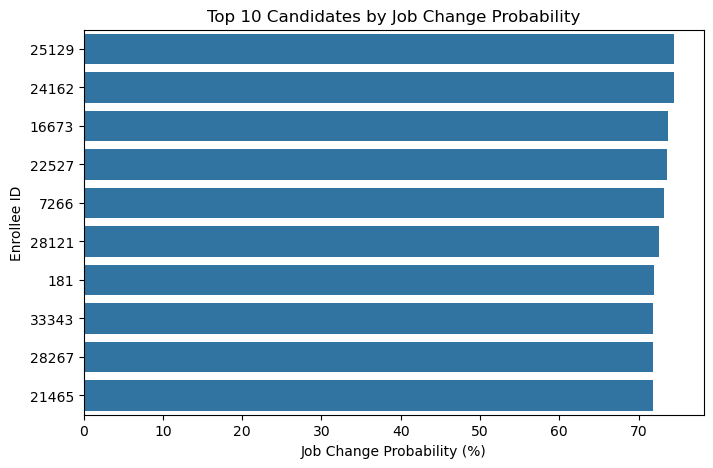

In [124]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_10_candidates,
    x="job_change_probability",
    y="enrollee_id",
    orient="h",
    order=top_10_candidates.sort_values("job_change_probability", ascending=False)["enrollee_id"]
)
plt.title("Top 10 Candidates by Job Change Probability")
plt.xlabel("Job Change Probability (%)")
plt.ylabel("Enrollee ID")
plt.show()

In [125]:
import pickle

model_package = {
    "model": final_xgb,
    "selector": final_selector,
    "feature_columns": X.columns.tolist()
}

with open("smart_recruitment_model.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("Pickle file created successfully!")

Pickle file created successfully!


In [126]:
import pickle

with open("smart_recruitment_model.pkl", "rb") as file:
    loaded_package = pickle.load(file)

loaded_model = loaded_package["model"]
loaded_selector = loaded_package["selector"]
feature_columns = loaded_package["feature_columns"]

print("Model loaded successfully!")
print("Number of features:", len(feature_columns))
print("Selected features:", loaded_selector.get_support().sum())

Model loaded successfully!
Number of features: 31
Selected features: 15
